# 公式テスト t2 — Homodimerization and Annihilation

> **出典（E-Cell4 公式）**: Tests / Homodimerization and Annihilation — https://ecell4.e-cell.org/tests/Homodimerization_and_Annihilation.html
>
> `A + A → ∅`（二量体化して消滅）の 2 分子反応。**巨視的(effective)速度 kon** と **微視的(intrinsic)速度 ka** の
> 使い分けを検証するテスト。ここでは巨視的モデルの ODE と Gillespie を実行、空間系は参照掲載。

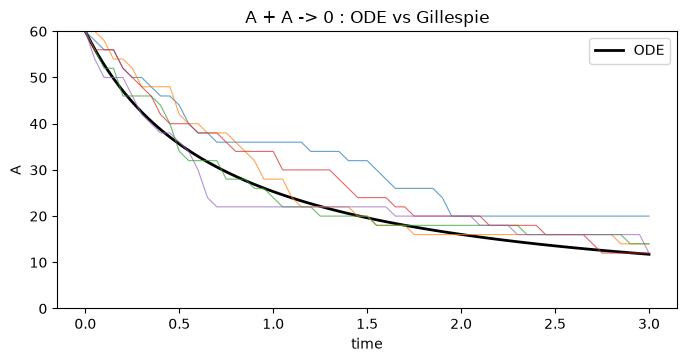

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4.prelude import *

D, radius, N_A, ka_factor = 1, 0.005, 60, 0.1
kD = 4 * np.pi * (radius * 2) * (D * 2)
ka = kD * ka_factor
kon = ka * kD / (ka + kD)
duration = 3
with species_attributes():
    A | {'radius': radius, 'D': D}
with reaction_rules():
    A + A > ~A2 | kon * 0.5   # 巨視的(effective)速度
m = get_model()

a = run_simulation(duration, y0={'A': N_A}, model=m, species_list=['A']).as_array()
plt.figure(figsize=(8,3.6))
plt.plot(a[:,0], a[:,1], 'k-', lw=2, label='ODE')
for seed in range(5):
    g = run_simulation(duration, y0={'A': N_A}, model=m, solver='gillespie', ndiv=60, species_list=['A'], rndseed=seed).as_array()
    plt.plot(g[:,0], g[:,1], lw=.8, alpha=.7)
plt.xlabel('time'); plt.ylabel('A'); plt.ylim(0, N_A); plt.legend(); plt.title('A + A -> 0 : ODE vs Gillespie'); plt.show()

## 巨視的 vs 微視的（公式コード・参照）

```python
# 巨視的(effective)モデル -> ODE / Gillespie / meso
with reaction_rules():
    A + A > ~A2 | kon * 0.5
# 微視的(intrinsic)モデル -> spatiocyte / egfrd（分子半径・拡散を陽に扱う）
with reaction_rules():
    A + A > ~A2 | ka
ret2 = ensemble_simulations(duration, ndiv=20, y0={'A':N_A}, model=m, solver=('spatiocyte', radius), repeat=30)
ret2 = ensemble_simulations(duration, ndiv=20, y0={'A':N_A}, model=m, solver=('egfrd', Integer3(4,4,4)), repeat=30)
```

**要点**: well-mixed 系では**巨視的速度 kon**（拡散と反応の合成）を使い、単分子空間系では**微視的速度 ka**（本来の反応速度）を
使う。両者は `kon = ka·kD/(ka+kD)` で関係づく——同じ現象を異なる解像度で正しく再現するための速度定数の対応。